## İş Problemi

Türkiye’nin en büyük online hizmet platformu olan Armut, hizmet verenler ile hizmet almak isteyenleri buluşturmaktadır.
Bilgisayarın veya akıllı telefonunun üzerinden birkaç dokunuşla temizlik, tadilat, nakliyat gibi hizmetlere kolayca
ulaşılmasını sağlamaktadır.
Hizmet alan kullanıcıları ve bu kullanıcıların almış oldukları servis ve kategorileri içeren veri setini kullanarak
Association Rule Learning ile ürün tavsiye sistemi oluşturulmak istenmektedir.


## Veri Seti

Veri seti müşterilerin aldıkları servislerden ve bu servislerin kategorilerinden oluşmaktadır.
Alınan her hizmetin tarih ve saat bilgisini içermektedir.

UserId: Müşteri numarası
ServiceId: Her kategoriye ait anonimleştirilmiş servislerdir. (Örnek : Temizlik kategorisi altında koltuk yıkama servisi)
Bir ServiceId farklı kategoriler altında bulanabilir ve farklı kategoriler altında farklı servisleri ifade eder.
(Örnek: CategoryId’si 7 ServiceId’si 4 olan hizmet petek temizliği iken CategoryId’si 2 ServiceId’si 4 olan hizmet mobilya montaj)
CategoryId: Anonimleştirilmiş kategorilerdir. (Örnek : Temizlik, nakliyat, tadilat kategorisi)
CreateDate: Hizmetin satın alındığı tarih

Ana Kategoriler ve Servis Türleri

1. Nakliyat: Evden eve nakliyat, şehirler arası nakliye, şehirler arası eşya taşıma ve parça eşya taşıma gibi hizmetler

2. Temizlik: Ev temizliği, boş ev temizliği, halı yıkama ve koltuk yıkama temizleme gibi

3. Tadilat ve Dekorasyon: Boya badana, ev boyama, cam balkon, duvar dekorasyon, fayans döşeme, iç mimar, mutfak dekorasyonu ve mutfak dolabı yapımı

4. Tamir ve Teknik Servis: Klima elektrik bağlantısı, klima gaz dolumu, klima montajı, klima servisi, elektrikçi, kombi servisi ve Demirdöküm kombi servisi

5. Özel Ders: İngilizce özel ders, ilkokul özel ders ve direksiyon dersi gibi eğitim odaklı servisler

6. Sağlık ve Diğer: Evde fizik tedavi gibi sağlık hizmetleri

7. Taşınma Paketi: "Evden Eve Nakliyat" alan bir kullanıcının, yeni evine geçmeden önce "Boş Ev Temizliği" veya "Boya Badana" hizmetlerine ihtiyaç duyma olasılığı oldukça yüksektir.

8. İklimlendirme ve Bakım Grubu: "Klima Montaj" yaptıran bir kullanıcıya, tamamlayıcı olarak "Klima Elektrik Bağlantısı" veya periyodik bakım için "Klima Gaz Dolumu" önerilebilir.

9. Mutfak Yenileme Grubu: "Mutfak Dekorasyonu" talebi oluşturan bir kullanıcıya, bu sürecin parçası olan "Mutfak Dolabı Yapımı" ve "Fayans Döşeme" hizmetleri birlikte önerilebilir.

10. Eğitim ve Gelişim: "İlkokul Özel Ders" alan bir veliye, dil gelişimi için "İngilizce Özel Ders" önerisi sunulması doğal bir çapraz satış (cross-sell) fırsatıdır.

In [232]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.expand_frame_repr", False)

### GÖREV 1: Veriyi Hazırlama

Adım 1: armut_data.csv dosyasınız okutunuz.


Adım 2: ServisID her bir CategoryID özelinde farklı bir hizmeti temsil etmektedir.
ServiceID ve CategoryID'yi "_" ile birleştirerek hizmetleri temsil edecek yeni bir değişken oluşturunuz.


In [233]:
df1 = pd.read_csv("armut_data.csv")
df = df1.copy()

print(df.head(15))
df.columns

    UserId  ServiceId  CategoryId           CreateDate
0    25446          4           5  2017-08-06 16:11:00
1    22948         48           5  2017-08-06 16:12:00
2    10618          0           8  2017-08-06 16:13:00
3     7256          9           4  2017-08-06 16:14:00
4    25446         48           5  2017-08-06 16:16:00
5    14354         15           1  2017-08-06 16:27:00
6    14162         21           5  2017-08-06 16:28:00
7    21230         46           4  2017-08-06 16:34:00
8    25446          6           7  2017-08-06 16:39:00
9    10659          4           5  2017-08-06 16:44:00
10   25446         47           7  2017-08-06 16:44:00
11   13471          5          11  2017-08-06 16:55:00
12   15137         11          11  2017-08-06 16:56:00
13    9036         48           5  2017-08-06 16:56:00
14   17982         48           5  2017-08-06 16:57:00


Index(['UserId', 'ServiceId', 'CategoryId', 'CreateDate'], dtype='str')

In [234]:
print(df.describe().T)
print(" ")
print(df.isnull().sum())
print(" ")
print(df.info())

               count          mean          std  min     25%      50%      75%      max
UserId      162523.0  13089.803862  7325.816060  0.0  6953.0  13139.0  19396.0  25744.0
ServiceId   162523.0     21.641140    13.774405  0.0    13.0     18.0     32.0     49.0
CategoryId  162523.0      4.325917     3.129292  0.0     1.0      4.0      6.0     11.0
 
UserId        0
ServiceId     0
CategoryId    0
CreateDate    0
dtype: int64
 
<class 'pandas.DataFrame'>
RangeIndex: 162523 entries, 0 to 162522
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   UserId      162523 non-null  int64
 1   ServiceId   162523 non-null  int64
 2   CategoryId  162523 non-null  int64
 3   CreateDate  162523 non-null  str  
dtypes: int64(3), str(1)
memory usage: 5.0 MB
None


Adım 3: Veri seti hizmetlerin alındığı tarih ve saatten oluşmaktadır, herhangi bir sepet tanımı (fatura vb. ) bulunmamaktadır.
Association Rule Learning uygulayabilmek için bir sepet (fatura vb.) tanımı oluşturulması gerekmektedir.

Burada sepet tanımı her bir müşterinin aylık aldığı hizmetlerdir. Örneğin; 7256 id'li müşteri 2017'in 8.ayında aldığı 9_4, 46_4 hizmetleri bir sepeti;
2017’in 10.ayında aldığı  9_4, 38_4  hizmetleri başka bir sepeti ifade etmektedir. Sepetleri unique bir ID ile tanımlanması gerekmektedir.
Bunun için öncelikle sadece yıl ve ay içeren yeni bir date değişkeni oluşturunuz. UserID ve yeni oluşturduğunuz date değişkenini "_"
ile birleştirirek ID adında yeni bir değişkene atayınız.



In [235]:
df.head(10)
print(df.shape)

(162523, 4)


Görev 1 fonksiyon olarak:

In [236]:
#Dataframedeki değişkenlerin type, number of unique ve value of unique değerlerini kontrol et

def check_df_unic(dataframe, th_print=10):
    """
    In this function, all df.columns are cheked. 
    For all variables type, null value, unique values and number of null and unique values caunt are printed.
    Parameters
    ----------
    dataframe: dataframe name
    col_name: which type of col need check

    Returns
    -------

        """
    pd.set_option("display.max_rows",th_print)
    print(f"Veri Seti Boyutu: {dataframe.shape}\n")
    for col in dataframe:
        print(f"Column Name: {col}")
        print(f"Null Count: {dataframe[col].isnull().sum()}")
        print(f"Unique Number: {dataframe[col].nunique()}")
        
        if dataframe[col].nunique()<th_print:
            print(f"Dtype: {dataframe[col].dtype}")
            print(f"Unique Value List: {dataframe[col].unique()}")
            print(f"Value Counts:\n{dataframe[col].value_counts().sort_values(ascending=False)}")
            
        print("---\n")
    pd.set_option("display.max_rows",20)

check_df_unic(df)

Veri Seti Boyutu: (162523, 4)

Column Name: UserId
Null Count: 0
Unique Number: 24826
---

Column Name: ServiceId
Null Count: 0
Unique Number: 50
---

Column Name: CategoryId
Null Count: 0
Unique Number: 12
---

Column Name: CreateDate
Null Count: 0
Unique Number: 117510
---



In [237]:
# değişken tiplerinin object olarak değiştirilmesi
df[["UserId","ServiceId","CategoryId"]] = df[["UserId","ServiceId","CategoryId"]].astype("object")

# invoice sütunu oluşturulması
df["Product_SC"] = "SC_"+df["ServiceId"].astype(str) + "_" + df["CategoryId"].astype(str)
print(df.head())
print(" ")

# yıl ve ay içeren date sütunu oluşturulması
df["date"] = pd.to_datetime(df["CreateDate"]).dt.to_period("M")
print(df.head())
print(" ")

df["Invoice_Id"] = df["UserId"].astype(str) + "_" + df["date"].astype(str)
print(df.head())


  UserId ServiceId CategoryId           CreateDate Product_SC
0  25446         4          5  2017-08-06 16:11:00     SC_4_5
1  22948        48          5  2017-08-06 16:12:00    SC_48_5
2  10618         0          8  2017-08-06 16:13:00     SC_0_8
3   7256         9          4  2017-08-06 16:14:00     SC_9_4
4  25446        48          5  2017-08-06 16:16:00    SC_48_5
 
  UserId ServiceId CategoryId           CreateDate Product_SC     date
0  25446         4          5  2017-08-06 16:11:00     SC_4_5  2017-08
1  22948        48          5  2017-08-06 16:12:00    SC_48_5  2017-08
2  10618         0          8  2017-08-06 16:13:00     SC_0_8  2017-08
3   7256         9          4  2017-08-06 16:14:00     SC_9_4  2017-08
4  25446        48          5  2017-08-06 16:16:00    SC_48_5  2017-08
 
  UserId ServiceId CategoryId           CreateDate Product_SC     date     Invoice_Id
0  25446         4          5  2017-08-06 16:11:00     SC_4_5  2017-08  25446_2017-08
1  22948        48        

In [238]:
check_df_unic(df)

Veri Seti Boyutu: (162523, 7)

Column Name: UserId
Null Count: 0
Unique Number: 24826
---

Column Name: ServiceId
Null Count: 0
Unique Number: 50
---

Column Name: CategoryId
Null Count: 0
Unique Number: 12
---

Column Name: CreateDate
Null Count: 0
Unique Number: 117510
---

Column Name: Product_SC
Null Count: 0
Unique Number: 50
---

Column Name: date
Null Count: 0
Unique Number: 13
---

Column Name: Invoice_Id
Null Count: 0
Unique Number: 71220
---



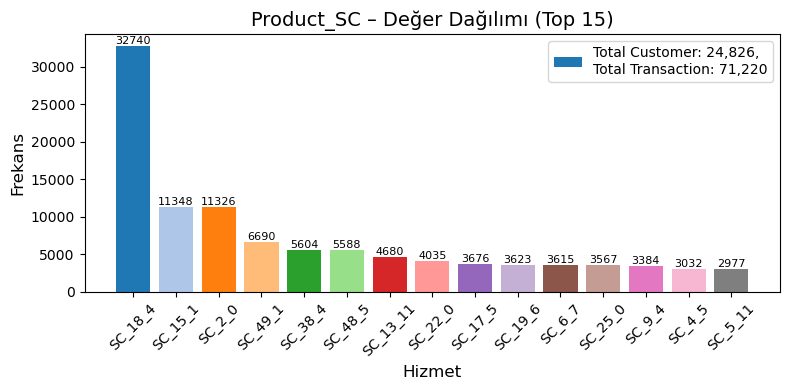

In [239]:
col = "Product_SC"
vc = df[col].value_counts().head(15)
# Global unique UserId
total_unique_users = df["UserId"].nunique()
# Global unique CART_ID
total_unique_box = df["Invoice_Id"].nunique()

plt.figure(figsize=(8,4))

# Her bar için otomatik farklı renk
colors = plt.cm.tab20(range(len(vc)))

bars = plt.bar(vc.index.astype(str), vc.values, color=colors)

plt.title(f"{col} – Değer Dağılımı (Top 15)", fontsize=14)
plt.xlabel("Hizmet", fontsize=12)
plt.ylabel("Frekans", fontsize=12)
plt.xticks(rotation=45)

# Sütun üstüne değer yazma
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )
     # Legend içine KPI ekleme
    plt.legend(
        [f"Total Customer: {total_unique_users:,},\nTotal Transaction: {total_unique_box:,}"],
        loc="upper right",
        frameon=True
    )
plt.tight_layout()
plt.show()

In [240]:
df.groupby(['UserId', 'Invoice_Id'], as_index=True).agg({     # Kullanıcı ve sepet bazında işlemleri grupla (index yerine kolon olarak tut)
    "Product_SC": lambda x: list(x)                           # Her sepet için alınan Product_SC değerlerini liste formatında birleştir
}).head(10)

Product_SC
UserId Invoice_Id                                        
0      0_2017-08                       [SC_46_4, SC_48_5]
       0_2017-09                        [SC_48_5, SC_4_5]
       0_2018-01               [SC_30_2, SC_7_3, SC_43_2]
       0_2018-04              [SC_30_2, SC_43_2, SC_14_7]
1      1_2017-10                                [SC_16_8]
       1_2018-03                                 [SC_1_4]
2      2_2018-05   [SC_11_11, SC_22_0, SC_22_0, SC_39_10]
       2_2018-06                                 [SC_9_4]
3      3_2017-08                               [SC_13_11]
       3_2017-09                                [SC_5_11]

### GÖREV 2: Birliktelik Kuralları Üretiniz

Adım 1: Aşağıdaki gibi sepet hizmet pivot table’i oluşturunuz.

In [241]:
# Hizmet         0_8  10_9  11_11  12_7  13_11  14_7  15_1  16_8  17_5  18_4..
# SepetID
# 0_2017-08        0     0      0     0      0     0     0     0     0     0..
# 0_2017-09        0     0      0     0      0     0     0     0     0     0..
# 0_2018-01        0     0      0     0      0     0     0     0     0     0..
# 0_2018-04        0     0      0     0      0     1     0     0     0     0..
# 10000_2017-08    0     0      0     0      0     0     0     0     0     0..


In [242]:
product_in_cart_df = pd.crosstab(
    df["Invoice_Id"],
    df["Product_SC"]
).gt(0).astype("int8")

product_in_cart_df.head(10)

Product_SC,SC_0_8,SC_10_9,SC_11_11,SC_12_7,SC_13_11,SC_14_7,SC_15_1,SC_16_8,SC_17_5,SC_18_4,SC_19_6,SC_1_4,SC_20_5,SC_21_5,SC_22_0,SC_23_10,SC_24_10,SC_25_0,SC_26_7,SC_27_7,SC_28_4,SC_29_0,SC_2_0,SC_30_2,SC_31_6,SC_32_4,SC_33_4,SC_34_6,SC_35_11,SC_36_1,SC_37_0,SC_38_4,SC_39_10,SC_3_5,SC_40_8,SC_41_3,SC_42_1,SC_43_2,SC_44_0,SC_45_6,SC_46_4,SC_47_7,SC_48_5,SC_49_1,SC_4_5,SC_5_11,SC_6_7,SC_7_3,SC_8_5,SC_9_4
Invoice_Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0_2017-08,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
0_2017-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
0_2018-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
0_2018-04,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
10000_2017-08,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
10000_2017-12,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10000_2018-03,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10001_2017-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10001_2018-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Adım 2: Birliktelik kurallarını oluşturunuz.


In [243]:
frequent_itemsets_SC = apriori(product_in_cart_df, min_support=0.01, use_colnames=True)
print(frequent_itemsets_SC)

     support                       itemsets
0   0.019728            frozenset({SC_0_8})
1   0.026523          frozenset({SC_11_11})
2   0.029374           frozenset({SC_12_7})
3   0.056627          frozenset({SC_13_11})
4   0.023406           frozenset({SC_14_7})
..       ...                            ...
51  0.011120  frozenset({SC_25_0, SC_22_0})
52  0.016568   frozenset({SC_2_0, SC_22_0})
53  0.013437   frozenset({SC_2_0, SC_25_0})
54  0.011191   frozenset({SC_38_4, SC_2_0})
55  0.010067   frozenset({SC_9_4, SC_38_4})

[56 rows x 2 columns]


In [244]:
rules_SC = association_rules(frequent_itemsets_SC, metric="support", min_threshold=0.01)

print(rules_SC)


              antecedents            consequents  antecedent support  consequent support   support  confidence      lift  representativity  leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski
0     frozenset({SC_2_0})  frozenset({SC_13_11})            0.130286            0.056627  0.012819    0.098394  1.737574               1.0  0.005442    1.046325       0.488074  0.073635   0.044274    0.162388
1   frozenset({SC_13_11})    frozenset({SC_2_0})            0.056627            0.130286  0.012819    0.226382  1.737574               1.0  0.005442    1.124216       0.449965  0.073635   0.110491    0.162388
2    frozenset({SC_15_1})    frozenset({SC_2_0})            0.120963            0.130286  0.033951    0.280673  2.154278               1.0  0.018191    1.209066       0.609539  0.156242   0.172915    0.270631
3     frozenset({SC_2_0})   frozenset({SC_15_1})            0.130286            0.120963  0.033951    0.260588  2.154278               1.0  0.018191    1.188833    

Adım 3: arl_recommender fonksiyonunu kullanarak en son 2_0 hizmetini alan bir kullanıcıya hizmet önerisinde bulununuz.

In [245]:
def arl_recommender(
    rules_df,
    product_id,
    rec_count=4,
    min_lift=1.0,
    min_confidence=0.0
):
    """
    Association Rule Learning kurallarına göre hizmet önerir.

    Parameters
    ----------
    rules_df : pandas.DataFrame
        Association rules tablosu.
    product_id : str
        Öneri üretilecek hizmet.
    rec_count : int
        Döndürülecek maksimum öneri sayısı.
    min_lift : float
        Kabul edilecek minimum lift değeri.
    min_confidence : float
        Kabul edilecek minimum confidence değeri.

    Returns
    -------
    list
        Önerilen hizmetler.
    """

    # Product'ın antecedent içerisinde bulunduğu kuralları seç
    product_rules = rules_df[
        rules_df["antecedents"].apply(
            lambda antecedent: product_id in antecedent
        )
    ].copy()

    # Kalitesi düşük kuralları ele
    product_rules = product_rules[
        (product_rules["lift"] > min_lift)
        & (product_rules["confidence"] >= min_confidence)
    ]

    # Önce lift, sonra confidence ve support
    product_rules = product_rules.sort_values(
        by=["lift", "confidence", "support"],
        ascending=False
    )

    recommendations = []
    seen = set()

    for consequent_set in product_rules["consequents"]:
        for recommended_product in consequent_set:

            # Aynı ürünü kendisine önerme ve tekrarları engelle
            if (
                recommended_product != product_id
                and recommended_product not in seen
            ):
                seen.add(recommended_product)
                recommendations.append(recommended_product)

            if len(recommendations) >= rec_count:
                return recommendations

    return recommendations

In [246]:
product_list = [
    "SC_18_4",
    "SC_25_0",
    "SC_2_0",
    "SC_13_11"
]

for product in product_list:
    recommendations = arl_recommender(
        rules_df=rules_SC,
        product_id=product,
        rec_count=4
    )

    print(
        f"Recommendation list for "
        f"\033[1;31m{product}\033[0m: {recommendations}"
    )

Recommendation list for SC_18_4: []
Recommendation list for SC_25_0: ['SC_22_0', 'SC_2_0']
Recommendation list for SC_2_0: ['SC_22_0', 'SC_25_0', 'SC_15_1', 'SC_13_11']
Recommendation list for SC_13_11: ['SC_2_0']


In [247]:
product_list2= ["SC_2_0", "SC_22_0", "SC_15_1", "SC_49_1"] # öneri yapılması istenen hizmetler

for product in product_list2:
    print(f"Recomendation list for \033[1;31m{product}\033[0m\t: {arl_recommender(rules_SC, product, 4)}")

Recomendation list for SC_2_0	: ['SC_22_0', 'SC_25_0', 'SC_15_1', 'SC_13_11']
Recomendation list for SC_22_0	: ['SC_25_0', 'SC_2_0']
Recomendation list for SC_15_1	: ['SC_33_4', 'SC_2_0', 'SC_38_4', 'SC_49_1']
Recomendation list for SC_49_1	: ['SC_15_1']


In [248]:
sorted_rules = rules_SC.sort_values("lift", ascending=False)
sorted_rules.columns

Index(['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski'], dtype='str')

In [249]:
# İlgili sütunları seçerek kuralların okunabilir halini oluşturuyoruz.
sorted_rules_new = sorted_rules[["antecedents", "consequents", "support", "confidence", "lift", "leverage"]]
sorted_rules_new

,antecedents,consequents,support,confidence,lift,leverage
11,frozenset({SC_22_0}),frozenset({SC_25_0}),0.011120,0.234043,5.456141,0.009082
10,frozenset({SC_25_0}),frozenset({SC_22_0}),0.011120,0.259247,5.456141,0.009082
19,frozenset({SC_38_4}),frozenset({SC_9_4}),0.010067,0.151234,3.653623,0.007312
18,frozenset({SC_9_4}),frozenset({SC_38_4}),0.010067,0.243216,3.653623,0.007312
4,frozenset({SC_15_1}),frozenset({SC_33_4}),0.011233,0.092861,3.400299,0.007929
5,frozenset({SC_33_4}),frozenset({SC_15_1}),0.011233,0.411311,3.400299,0.007929
13,frozenset({SC_22_0}),frozenset({SC_2_0}),0.016568,0.348700,2.676409,0.010378
12,frozenset({SC_2_0}),frozenset({SC_22_0}),0.016568,0.127169,2.676409,0.010378
15,frozenset({SC_25_0}),frozenset({SC_2_0}),0.013437,0.313257,2.404371,0.007849
14,frozenset({SC_2_0}),frozenset({SC_25_0}),0.013437,0.103136,2.404371,0.007849


In [253]:
recommendations = arl_recommender(
    rules_df=rules_SC,
    product_id="SC_2_0",
    rec_count=4
)

print("SC_2_0 hizmeti için öneriler:", recommendations)

SC_2_0 hizmeti için öneriler: ['SC_22_0', 'SC_25_0', 'SC_15_1', 'SC_13_11']
